### Implementation

In [1]:
import numpy as np
import pandas as pd
from collections import Counter

In [2]:
def minkowski_distance(p1, p2, order = 2):
    return np.power(np.sum(np.power(abs(p1-p2), order)), 1/order)

class KNearestNeighbors:
    def __init__(self, k = 3):
        """
        Instantiate the K nearest nerighbor class
        :param: k - number of nearest neighbors to predict class labels from
        """
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        """
        Fit the model. As KNN is a lazy learner no training (optimisation) happens at this stage
        """
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        

    def predict(self, X):
        """
        Predict labels for given observations
        """
        X = np.array(X)
        return np.array([self._predict_single(i) for i in X])
        
        
    def _predict_single(self, x):
        # distance of observation from every training sample
        distances = np.array([minkowski_distance(i, x, 2) for i in self.X_train])
        

        # find the indices of the nearest neighbors
        indices = np.argsort(distances)[:self.k]
        

        # get labels corresponding to the indices
        labels = self.y_train[indices]
        

        # return mode of the labels
        mode = Counter(labels).most_common(1)[0][0]
        return mode
    

In [3]:
iris = pd.read_csv('iris.csv')

In [4]:
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# 1. EDA

<Axes: title={'center': 'Sepal Length v/s Sepal Width'}, xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

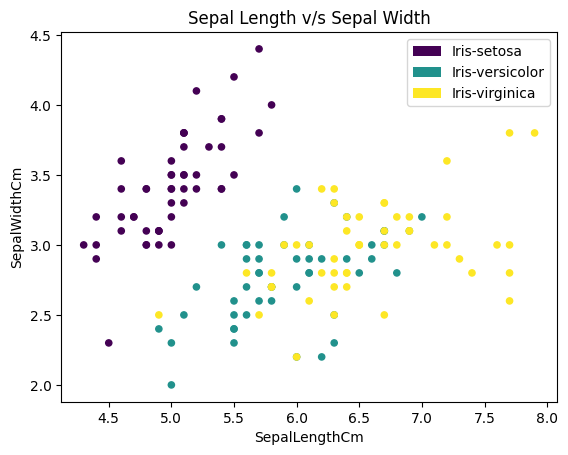

In [6]:
iris.plot.scatter(x = 1 ,y = 2, c = 5, title = 'Sepal Length v/s Sepal Width')

<Axes: title={'center': 'Petal Length v/s Petal Width'}, xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

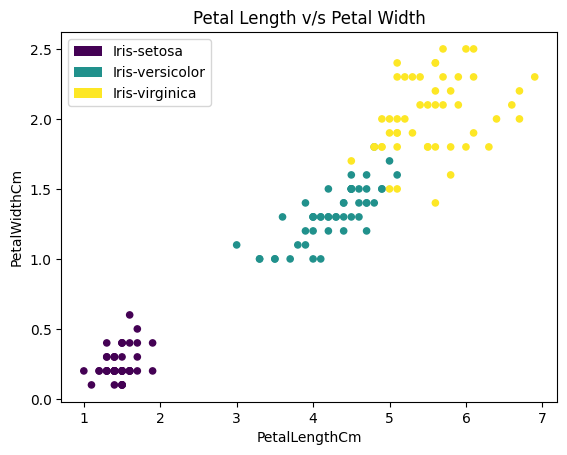

In [7]:
iris.plot.scatter(x = 3 ,y = 4, c = 5, title = 'Petal Length v/s Petal Width')

In [8]:
# Features

X = iris.iloc[:,1:5]
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
# Labels

y = iris.Species
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: str

In [10]:
# 2. train - test data

np.random.seed(42)
random_ = np.random.rand(iris.shape[0])

train_ids = random_ < .8
test_ids = random_ >= .8

X_train, y_train, X_test, y_test = X[train_ids], y[train_ids], X[test_ids], y[test_ids]

print(X_train.shape)
print(X_test.shape)

(119, 4)
(31, 4)


In [11]:
# 3. Evaluation Metric

def accuracy(actuals, preds):
    return sum(actuals == preds)/len(actuals)

In [12]:
# 4. Train model and make predictions

# instantiate
knn = KNearestNeighbors(k = 5)

# fit
knn.fit(X_train, y_train)

# predict
y_test_pred = knn.predict(X_test)
y_test_pred

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica'], dtype='<U15')

In [13]:
# 5. Evaluate the model

accuracy(y_test, y_test_pred)

1.0

In [14]:
# validate against scikit-learn

from sklearn.neighbors import KNeighborsClassifier

knn2 = KNeighborsClassifier(n_neighbors = 5, algorithm = 'brute')

knn2.fit(X_train, y_train)

y_test_pred2 = knn2.predict(X_test)

accuracy(y_test, y_test_pred2)

1.0

### Note


Q1. While calculating mode (most common) should all neighbors have the same weightage?

A. The nearest neighbor should be the largest indicator of the label of the unknown sample. In practice, we take a weighted mode as the class label of the unknown sample, where weight = 1/distance. Doing such helps in cases where there is high data imbalance.


Q2. How does the error of a KNN classifier compare with a Bayes Optimal Classifier?

A: For an infinitly large training data set (n_samples -> inf), the error-rate of the 1-Nearest Neighbor classifier is never more than twice the error rate of the Bayes Optimal classifier - Cover-Hart (1967). 

For a binary classification problem, the conditional probability of error for 1-NN is P(error|x) = 2p(x)(1- p(x)) where p(x) is the probability of the majority class given x.

The Bayes risk for that same point is 1-p(x)

Since 2p(1-p) <= 2(1-P), the 1-NN error is at most twice as bad as the Bayes Optimal Classifier. This shows that even with a simple lazy 'memeorise your neighbor' algorithm you will asymptotically converge to the optimal decision boundary, within a factor two.


Q3. Curse of dimensionality

A. As the numbers of features increases, all points are equally far out from each other and there are no "nearest neighbors" anymore. The algorithm has a time complexity of O(N*D) where N: number of samples, d: number of dimensions or features, this also makes its use prohibitive for high dimensional data. It is optimally used for 3-5 features 

Q4: How can k-NearestNeighbors be sped up?

A: Variants of this algorithm repeatedly partition the search space or tries to identify cluster centers. The search of the nearest neighbor is restricted to a partition or cluster thus speeding up the algorithm significantly